In [ ]:
!pip install -Uq tfp-nightly[jax]
!pip install inference_gym
!pip install tf-nightly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 121.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 390.9/390.9 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 636.6/636.6 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 136.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 32.6 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requ

In [ ]:
import numpy as np
from copy import deepcopy
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from google.colab import drive

# from matplotlib.pyplot import *

import os
# in case jax eats up my GPU RAM
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

import jax
from jax import random
from jax import numpy as jnp

# from inference_gym import using_jax as gym

from tensorflow_probability.substrates import jax as tfp
tfd = tfp.distributions
from inference_gym import using_jax as gym
tfb = tfp.bijectors

from tensorflow_probability.substrates import numpy as tfp_np
tfd_np = tfp_np.distributions

import matplotlib.pyplot as plt

import pandas as pd

import gc

# check if this is run on a gpu
print(jax.devices())
print(jax.default_backend())

import warnings
warnings.filterwarnings('ignore')

import psutil

process = psutil.Process(os.getpid())

def mem(msg):
    print(f"{msg}: {process.memory_info().rss / 1024**2:.1f} MB")

[CudaDevice(id=0)]
gpu


In [ ]:
max_warmup = 1000
warmup_window = 100

window_array = np.append(np.repeat(10, 10),
                      np.repeat(warmup_window, max_warmup // warmup_window - 1))

warmup_length = np.repeat(10, len(window_array))
for i in range(len(warmup_length) - 1):
    warmup_length[i + 1] = warmup_length[i] + window_array[i + 1]

# reduce K and M to K=4, M=128
repitition = 10
num_chains_short = 512
num_super_chains = 4

In [ ]:
# quantiles for chi squared with df = 1
chi_up = 3.841459 # 95th quantile for chi squared with df = 1
chi_lo = 0.00393214  # 05th quantile for chi squared with df = 1
tau = 1e-4
M = num_chains_short // num_super_chains
nRhat_lower = np.sqrt(1 + 1 / M + tau)
eps_lower = nRhat_lower - 1
bound = [chi_lo / num_chains_short, chi_up / num_chains_short]
threshold = eps_lower

In [ ]:
def kernel_setup(warmup_length, sampling_length,
                 num_sub_chains,num_super_chains,
                 naive, initialize_fn,ranKey,
                 target_log_prob_fn, init_step_size):
    num_warmup_short, num_sampling_short = warmup_length, sampling_length
    total_samples_short = num_warmup_short + num_sampling_short

    kernel_short = tfp.mcmc.HamiltonianMonteCarlo(target_log_prob_fn, init_step_size, 1)
    kernel_short = tfp.experimental.mcmc.GradientBasedTrajectoryLengthAdaptation(kernel_short, num_warmup_short)
    kernel_short = tfp.mcmc.DualAveragingStepSizeAdaptation(
        kernel_short, num_warmup_short, target_accept_prob = 0.75,  #0.75,
        reduce_fn = tfp.math.reduce_log_harmonic_mean_exp)

    if (naive):
       # initialize each chain at a different location
        initial_state = initialize_fn((num_sub_chains,),key=ranKey)
        initial_state_super = initial_state
    else:
        # Chains within a super chain are all initialized at the same location
        initial_state_super = initialize_fn((num_super_chains,), key=ranKey)
        initial_state = jnp.repeat(initial_state_super, num_sub_chains // num_super_chains,axis = 0)

    return kernel_short, initial_state, total_samples_short, initial_state_super


def _reduce_variance_interval(x, axis=None, biased=True, keepdims=False):
    # ddof=0 is biased variance (N), ddof=1 is unbiased variance (N-1)
    ddof = 0 if biased else 1
    return jnp.var(x, axis=axis, ddof=ddof, keepdims=keepdims)


def nested_rhat_constrained(result_state, num_super_chains,idx):
     # since we use only N=1, W_k is reduced to 0
    num_sub_chains = result_state.shape[0] // num_super_chains
    num_dimensions = result_state.shape[1]

    chain_states = result_state.reshape(1, -1, num_sub_chains, num_dimensions)
    # chain_states.shape = (1,16,128,2), so it is (N,K,M,D).
    # f_bar 1*k, mean_subchain.shape =(1,16,2), (N,K,D)
    mean_subchain = jnp.mean(chain_states, axis=2)

    variance_chain = _reduce_variance_interval(chain_states, axis=2, biased=False)
    # print(variance_chain.shape) # (1,16,2)
    W = jnp.mean(variance_chain, axis=1)
    # print(f"W dim: {W.shape}") # (1,2)
    B = _reduce_variance_interval(mean_subchain, axis=1, biased=False) # variance of between super chain

    r_hat = jnp.sqrt(1+B/W)[:,idx]
    return r_hat

def mse_calculation(result, mean_benchmark,
                    var_benchmark, mse_list):
    mc_mean = result.mean(axis=0)
    squared_error = (mc_mean - mean_benchmark)**2
    factor = 1/var_benchmark
    factored_sq_err = factor*squared_error
    mse = (factored_sq_err).mean()
    mse_list.append(mse)
    return mse_list, factored_sq_err

# add a switch for recording the states
# change the trace functionality so that it only record the last states
def simulation(keys, initialize_fn,
               warmup_length,sampling_length,
               naive, repitition,
               MSE_list, R_Hat_list,
               num_dim, state_list,
               mean_benchmark,var_benchmark,
               num_super_chains,num_sub_chains,
               target_log_prob_fn, init_step_size):
    result_mse = []

    for sim in range(repitition):
        kernel_short, initial_state, total_samples_short, initial_state_super = kernel_setup(warmup_length,sampling_length,
                                           num_sub_chains, num_super_chains,
                                           naive, initialize_fn,keys[sim],
                                           target_log_prob_fn, init_step_size)
        result_short = tfp.mcmc.sample_chain(
            total_samples_short, initial_state, kernel = kernel_short,
            seed =keys[sim], trace_fn=None)[-1,:,:]
        state_record = {
            "Warmup Length": warmup_length,
                        "Iteration": sim,
                        "Final Position":np.asarray(result_short),
                        "Initial Position":np.asarray(initial_state_super)
        }

        state_list.append(state_record)

        result_mse, factored_sq_err = mse_calculation(result_short,mean_benchmark,var_benchmark,result_mse)

        for dim in range(num_dim):
            new_r_hat = nested_rhat_constrained(result_short, num_super_chains, dim)
            R_Hat_list.append({
                "Warmup Length": warmup_length,
                "Iteration":sim,
                "Dimension": dim,
                "Rhat": new_r_hat[-1],
                "MSE":factored_sq_err[dim]
                })
        del state_record, result_short, kernel_short, initial_state
        del initial_state_super, total_samples_short
        gc.collect()

    result_mse = np.array(result_mse)
    result_mse_best = result_mse.min(axis=0)
    result_mse_worst = result_mse.max(axis=0)
    mean_mse = result_mse.mean(axis=0)

    MSE_list.append({"Warmup Length":warmup_length,"Avg MSE": mean_mse,
                      "Best MSE": result_mse_best,"Worst MSE": result_mse_worst})
    if naive:
          print(f"Naive initialization. Warmup Length: {warmup_length}; mean of MSE is: {mean_mse}")
    else:
        print(f"Constrained initialization. Warmup Length: {warmup_length}; mean of MSE is: {mean_mse}")
    del result_mse
    gc.collect()
    jax.clear_caches()

In [ ]:
target = gym.targets.VectorModel(gym.targets.Banana(),
                                 flatten_sample_transformations=True)
num_dimensions = target.event_shape[0]
init_step_size = 1.

def target_log_prob_fn(x):
  """Unnormalized, unconstrained target density.

  This is a thin wrapper that applies the default bijectors so that we can
  ignore any constraints.
  """
  y = target.default_event_space_bijector(x)
  fldj = target.default_event_space_bijector.forward_log_det_jacobian(x)
  return target.unnormalized_log_prob(y) + fldj

# NOTE: Avoid initials centered around the true mean.
offset = 2
def initialize (shape, key):
  return 10 * random.normal(key, shape + (num_dimensions,)) + offset

In [ ]:
# Get some estimates of the mean and variance.
try:
  mean_est = target.sample_transformations['identity'].ground_truth_mean
except:
  print('no ground truth mean')
  mean_est = (result.all_states[num_warmup:, :]).mean(0).mean(0)
try:
  var_est = target.sample_transformations['identity'].ground_truth_standard_deviation**2
except:
  print('no ground truth std dev')
  var_est = ((result.all_states[num_warmup:, :]**2).mean(0).mean(0) -
             mean_est**2)
mean_benchmark = mean_est
var_benchmark = var_est

In [ ]:
#simulation part:
MSE_constrained_list = []
MSE_naive_list = []
R_Hat_constrained_list = []
R_Hat_naive_list = []
state_list_constrained = []
state_list_naive = []

In [ ]:
base_key = random.PRNGKey(0)
keys = random.split(base_key, repitition)

for length in warmup_length:
  mem(f"Simulation start")
  simulation(
            keys,initialize,
            length,1,
            False, repitition,
            MSE_constrained_list,R_Hat_constrained_list,
            num_dimensions, state_list_constrained,
            mean_benchmark,var_benchmark,
            num_super_chains,num_chains_short,
            target_log_prob_fn, init_step_size)
  simulation(
            keys,initialize,
            length,1,
            True, repitition,
            MSE_naive_list,R_Hat_naive_list,
            num_dimensions, state_list_naive,
            mean_benchmark,var_benchmark,
            num_super_chains,num_chains_short,
            target_log_prob_fn, init_step_size)

Simulation start: 1455.9 MB
Constrained initialization. Warmup Length: 10; mean of MSE is: 0.2678084075450897
Naive initialization. Warmup Length: 10; mean of MSE is: 0.014006051234900951
Simulation start: 1764.1 MB
Constrained initialization. Warmup Length: 20; mean of MSE is: 0.2550157606601715
Naive initialization. Warmup Length: 20; mean of MSE is: 0.012414136901497841
Simulation start: 1767.2 MB
Constrained initialization. Warmup Length: 30; mean of MSE is: 0.22729802131652832
Naive initialization. Warmup Length: 30; mean of MSE is: 0.010504430159926414
Simulation start: 1768.5 MB
Constrained initialization. Warmup Length: 40; mean of MSE is: 0.20367471873760223
Naive initialization. Warmup Length: 40; mean of MSE is: 0.01056324876844883
Simulation start: 1772.8 MB
Constrained initialization. Warmup Length: 50; mean of MSE is: 0.17669077217578888
Naive initialization. Warmup Length: 50; mean of MSE is: 0.010008862242102623
Simulation start: 1772.9 MB
Constrained initialization. Wa

In [ ]:
MSE_c_df = pd.DataFrame(MSE_constrained_list)
R_Hat_c_df = pd.DataFrame(R_Hat_constrained_list)
state_c_df = pd.DataFrame(state_list_constrained)
MSE_n_df = pd.DataFrame(MSE_naive_list)
R_Hat_n_df = pd.DataFrame(R_Hat_naive_list)
state_n_df = pd.DataFrame(state_list_naive)

In [ ]:
def potential(theta1, theta2):
    """
    Negative log density up to an additive constant for:

        theta1 ~ Normal(0, 10)
        theta2 | theta1 ~ Normal(
            0.03 * (theta1^2 - 100),
            1
        )
    """

    conditional_mean = 0.03 * (theta1**2 - 100)

    return (
        0.5 * (theta1 / 10)**2
        + 0.5 * (theta2 - conditional_mean)**2
    )

def plot_rosenbrock_final_positions(
        state_df,
        metrics_df,
        iteration,
        params):

    K, M, N = params

    warmup_lengths = [
        10, 20, 30, 40, 50,
        100, 200, 500, 1000
    ]

    # --------------------------------------------------
    # Fixed plotting configuration
    # --------------------------------------------------

    x_limits = (-40, 40)
    y_limits = (-15, 45)

    theta1 = np.linspace(
        x_limits[0],
        x_limits[1],
        500
    )

    theta2 = np.linspace(
        y_limits[0],
        y_limits[1],
        500
    )

    T1, T2 = np.meshgrid(theta1, theta2)

    Z = potential(T1, T2)

    # Fixed contour levels
    levels = np.linspace(0, 20, 5)

    # --------------------------------------------------
    # Create 3x3 subplot grid
    # --------------------------------------------------

    fig, axes = plt.subplots(
        3,
        3,
        figsize=(15, 12),
        sharex=True,
        sharey=True
    )

    axes = axes.flatten()

    # --------------------------------------------------
    # Plot each warmup length
    # --------------------------------------------------

    for ax, warmup in zip(axes, warmup_lengths):

        # --------------------------------------------------
        # Retrieve final positions
        # --------------------------------------------------

        state_row = state_df[
            (state_df["Warmup Length"] == warmup)
            &
            (state_df["Iteration"] == iteration)
        ]

        # --------------------------------------------------
        # Retrieve metrics for this warmup and iteration
        # --------------------------------------------------

        metrics_row = metrics_df[
            (metrics_df["Warmup Length"] == warmup)
            &
            (metrics_df["Iteration"] == iteration)
        ]

        # Calculate average across all dimensions
        if not metrics_row.empty:

            avg_mse = metrics_row["MSE"].mean()
            avg_rhat = metrics_row["Rhat"].mean()

        else:

            avg_mse = None
            avg_rhat = None

        # --------------------------------------------------
        # Draw identical contours
        # --------------------------------------------------

        ax.contour(
            T1,
            T2,
            Z,
            levels=levels,
            colors="black",
            linewidths=0.8
        )

        # --------------------------------------------------
        # No state data
        # --------------------------------------------------

        if state_row.empty:

            ax.set_title(
                f"Warmup = {warmup}\n"
                f"No state data"
            )

            continue

        # --------------------------------------------------
        # Retrieve final positions
        # --------------------------------------------------

        final_positions = state_row.iloc[0]["Final Position"]

        # --------------------------------------------------
        # Plot MCMC positions
        # --------------------------------------------------

        ax.scatter(
            final_positions[:, 0],
            final_positions[:, 1],
            s=10,
            alpha=0.6,
            color="red"
        )

        # --------------------------------------------------
        # Subplot title
        # --------------------------------------------------

        if avg_mse is not None:

            ax.set_title(
                f"Warmup = {warmup}\n"
                f"Avg MSE = {avg_mse:.4f}, "
                f"Avg R-hat = {avg_rhat:.4f}"
            )

        else:

            ax.set_title(
                f"Warmup = {warmup}\n"
                f"No metric data"
            )

        ax.grid(
            True,
            linestyle="--",
            alpha=0.3
        )

    # --------------------------------------------------
    # Force identical axis limits
    # --------------------------------------------------

    for ax in axes:
        ax.set_xlim(x_limits)
        ax.set_ylim(y_limits)

    # --------------------------------------------------
    # Axis labels
    # --------------------------------------------------

    for ax in axes[6:]:
        ax.set_xlabel(r"$\theta_1$")

    for ax in axes[::3]:
        ax.set_ylabel(r"$\theta_2$")

    # --------------------------------------------------
    # Overall title
    # --------------------------------------------------

    fig.suptitle(
        f"Final MCMC Positions by Warmup Length\n"
        f"Iteration = {iteration}, "
        f"K = {K}, "
        f"M = {M}, "
        f"N = {N}",
        fontsize=16
    )

    # Leave room for overall title
    plt.tight_layout(
        rect=[0, 0, 1, 0.94]
    )

    plt.show()

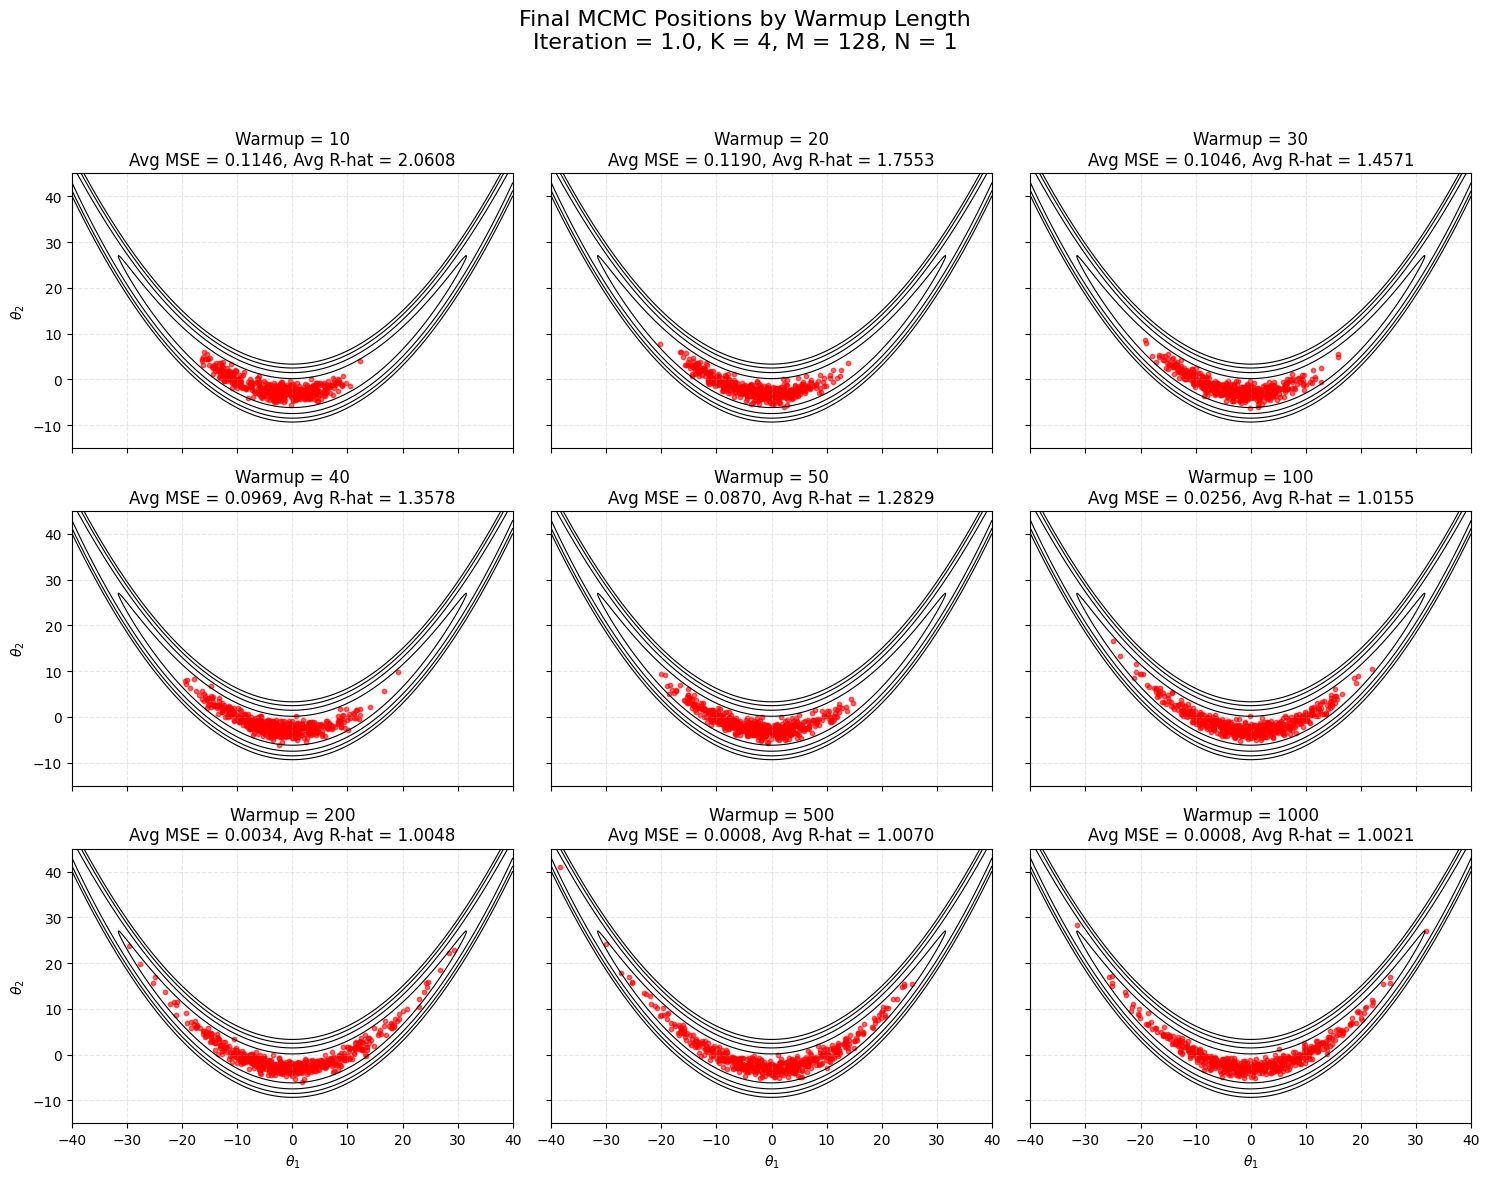

In [ ]:
plot_rosenbrock_final_positions(
    state_c_df,
    R_Hat_c_df,
    iteration=1.0,
    params = (num_super_chains,M,1))

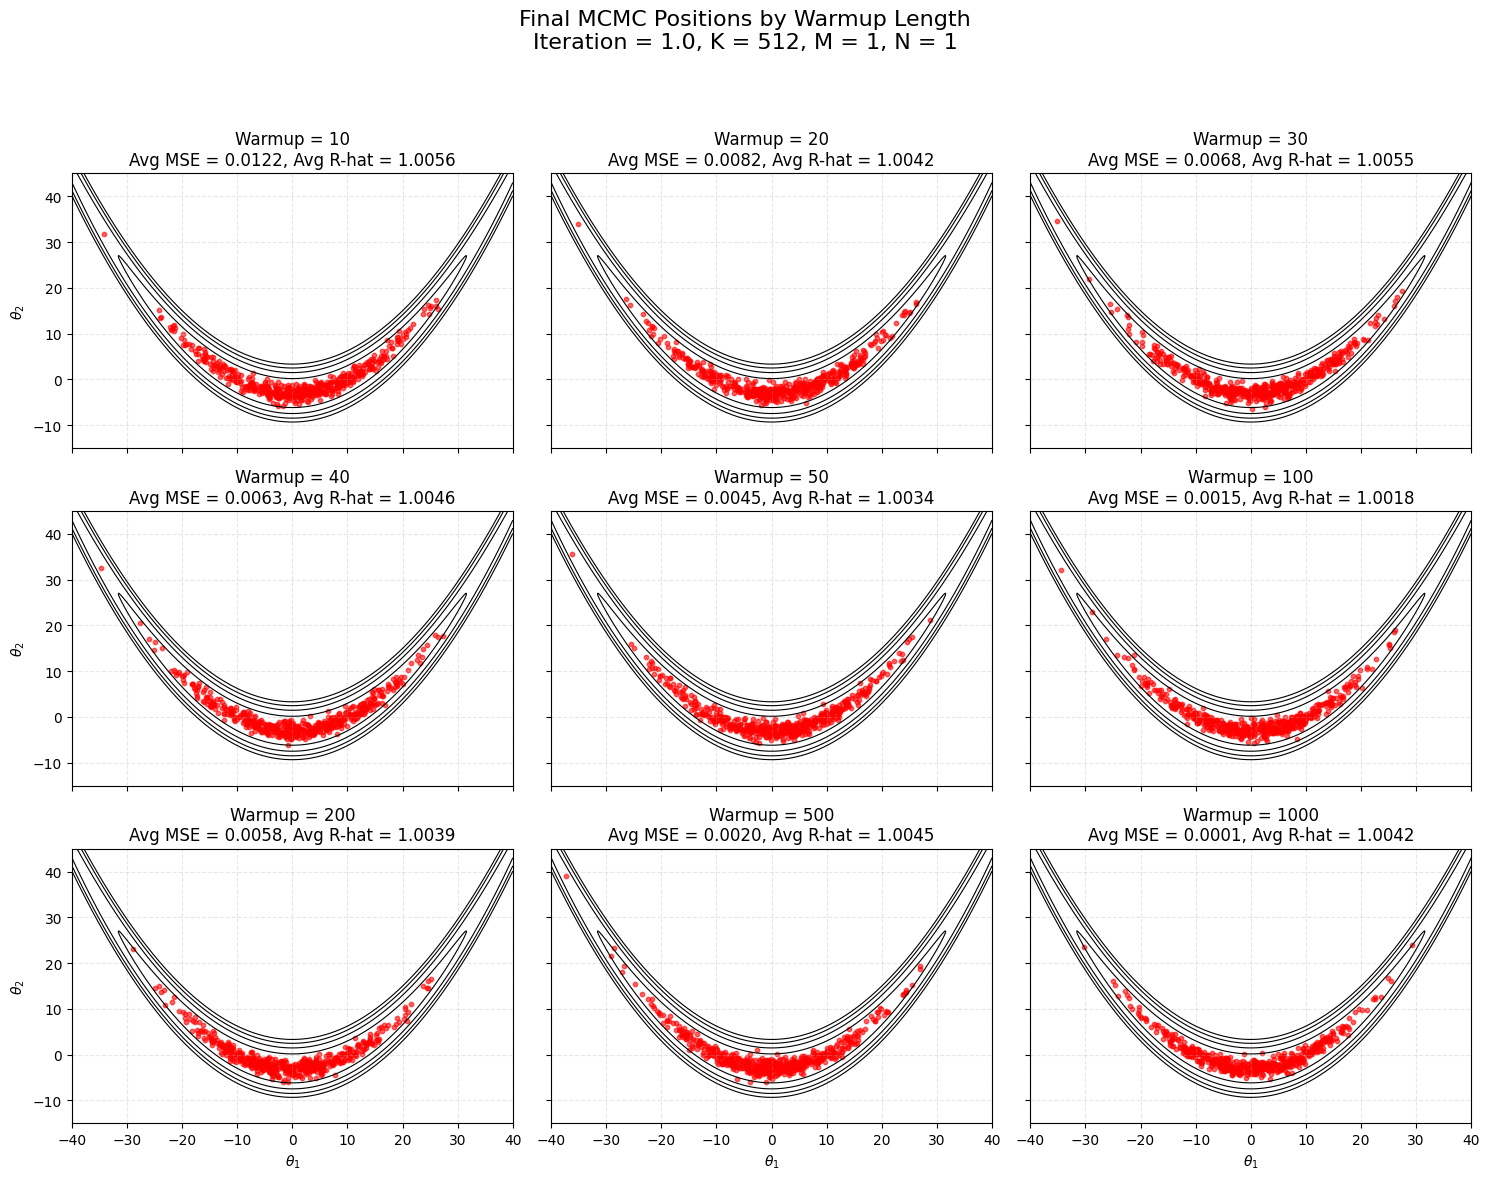

In [ ]:
plot_rosenbrock_final_positions(
    state_n_df,
    R_Hat_n_df,
    iteration=1.0,
    params = (num_chains_short,1,1)
)

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
state_c_df.to_pickle(
    '/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Paper_Distribution/gridPlot/Rosen_Trace_C.pkl'
)

state_n_df.to_pickle(
    '/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Paper_Distribution/gridPlot/Rosen_Trace_N.pkl'
)

In [ ]:
R_Hat_c_df.to_pickle(
    '/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Paper_Distribution/gridPlot/Rhat_C.pkl'
)

R_Hat_n_df.to_pickle(
    '/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Paper_Distribution/gridPlot/Rhat_N.pkl'
)

In [ ]:
MSE_c_df.to_pickle(
    '/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Paper_Distribution/gridPlot/MSE_C.pkl'
)

MSE_n_df.to_pickle(
    '/content/drive/MyDrive/JHU Stuff/Capstone/pkl_Paper_Distribution/gridPlot/MSE_N.pkl'
)